# Low-density parity-check Code
## Density Evolution

In [2]:
import numpy as np
from scipy.stats import poisson

In [3]:
def DE_LDPC(d_l, d_r, num_iterations=60):
    delta_list = np.linspace(0.01, 0.1, 1000) 
    threshold = 0

    for delta in delta_list:

        X = 1  
        for _ in range(num_iterations):
            X = (1 - (1 - X) ** (d_r-1)) ** (d_l-1) * delta
        if X < 1e-6: threshold = delta

    print(f"Threshold for LDPC ({d_l}, {d_r}) is about {threshold:.5f}")
    print(f"Code rate: {1-d_l/d_r}, overhead: {(1/(1-d_l/d_r)-1)*100:.5f}%")

In [4]:
# Parameters
d_l = 3
d_r = 100
DE_LDPC(d_l, d_r)

Threshold for LDPC (3, 100) is about 0.02441
Code rate: 0.97, overhead: 3.09278%


In [5]:
# Parameters
d_l = 4
d_r = 80
DE_LDPC(d_l, d_r)

Threshold for LDPC (4, 80) is about 0.03838
Code rate: 0.95, overhead: 5.26316%


In [6]:
# Parameters
d_l = 5
d_r = 80
DE_LDPC(d_l, d_r)

Threshold for LDPC (5, 80) is about 0.04360
Code rate: 0.9375, overhead: 6.66667%


In [7]:
# Parameters
d_l = 6
d_r = 90
DE_LDPC(d_l, d_r)

Threshold for LDPC (6, 90) is about 0.04216
Code rate: 0.9333333333333333, overhead: 7.14286%


In [8]:
d_l = 4
d_r = 40
DE_LDPC(d_l, d_r)

Threshold for LDPC (4, 40) is about 0.07694
Code rate: 0.9, overhead: 11.11111%


## Monolithic LDPC code

In [4]:
import matplotlib.pyplot as plt

In [5]:
def generate_regular_ldpc(n_var=3000, d_v=4, d_c=40):
    """
    Generate a regular (d_v, d_c) LDPC matrix H.
    @param(n_var): number of variable nodes
    @param(d_v): degree of each variable node
    @param(d_c): degree of each check node

    @return: np.ndarray
    """
    n_check = n_var * d_v // d_c
    assert n_check * d_c == n_var * d_v, "d_v * n_var must be divisible by d_c"
    H = np.zeros((n_check, n_var), dtype=int)

    var_indices = np.repeat(np.arange(n_var), d_v)
    check_indices = np.repeat(np.arange(n_check), d_c)
    
    np.random.shuffle(check_indices)
    used_pairs = set()
    
    for c, v in zip(check_indices, var_indices):
        while (c, v) in used_pairs:
            c = np.random.choice(check_indices)
        H[c, v] += 1
        used_pairs.add((c, v))
        assert H[c, v] <= 1
    
    return H


In [7]:
generate_regular_ldpc()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(300, 3000))

In [6]:

def bec_channel(x, erasure_prob=0.1):
    received = x.copy()
    erasures = np.random.rand(len(x)) < erasure_prob
    received[erasures] = -1  
    return received


In [7]:
def peeling_decoder(H, received):
    n_check, n_var = H.shape
    decoded = received.copy()

    while True:
        progress = False
        for i in range(n_check):
            idxs = np.where(H[i, :] == 1)[0]
            known = idxs[decoded[idxs] != -1]
            unknown = idxs[decoded[idxs] == -1]
            if len(unknown) == 1:
                j = unknown[0]
                parity = np.sum(decoded[known]) % 2
                decoded[j] = parity
                progress = True
        if not progress:
            break
    return decoded

In [12]:
def run_experiment(n, d_v, d_c, start=0.01, end=0.1):
    num_trials = 1000
    epsilons = np.linspace(start, end, 10)  

    success_rates = []

    np.random.seed(np.random.randint(1, 10000))
    H = generate_regular_ldpc(n_var=n, d_v=d_v, d_c=d_c)

    for eps in epsilons:
        success_count = 0
        for _ in range(num_trials):
            codeword = np.zeros(n, dtype=int)  
            received = bec_channel(codeword, eps)
            decoded = peeling_decoder(H, received)
            if -1 not in decoded and np.all(np.mod(H @ decoded, 2) == 0):
                success_count += 1
        success_rate = success_count / num_trials
        success_rates.append(success_rate)
        print(f"Epsilon={eps:.3f}, Success Rate={success_rate:.3f}")

    plt.plot(epsilons, success_rates, marker='o')
    plt.xlabel('Erasure Probability (epsilon)')
    plt.ylabel('Success Rate')
    plt.title(f'(dv={d_v}, dc={d_c}) LDPC over BEC')
    plt.grid(True)
    plt.show()

Epsilon=0.010, Success Rate=0.980
Epsilon=0.012, Success Rate=0.974
Epsilon=0.014, Success Rate=0.917
Epsilon=0.017, Success Rate=0.835
Epsilon=0.019, Success Rate=0.714
Epsilon=0.021, Success Rate=0.570
Epsilon=0.023, Success Rate=0.407
Epsilon=0.026, Success Rate=0.280
Epsilon=0.028, Success Rate=0.162
Epsilon=0.030, Success Rate=0.090


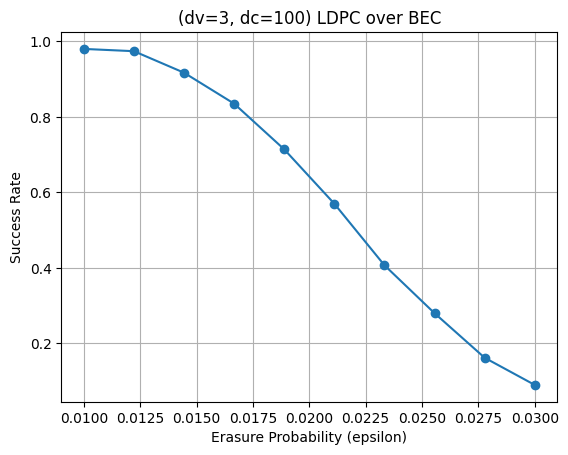

In [ ]:
n = 1000; d_v = 3; d_c = 100
start, end = 0.01, 0.03
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.010, Success Rate=0.994
Epsilon=0.012, Success Rate=0.984
Epsilon=0.014, Success Rate=0.980
Epsilon=0.017, Success Rate=0.925
Epsilon=0.019, Success Rate=0.841
Epsilon=0.021, Success Rate=0.645
Epsilon=0.023, Success Rate=0.449
Epsilon=0.026, Success Rate=0.261
Epsilon=0.028, Success Rate=0.138
Epsilon=0.030, Success Rate=0.044


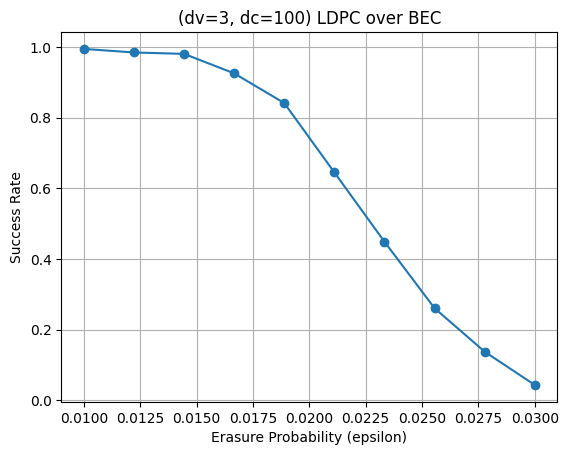

In [ ]:
n = 2000; d_v = 3; d_c = 100
start, end = 0.01, 0.03
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.010, Success Rate=0.995
Epsilon=0.012, Success Rate=0.997
Epsilon=0.014, Success Rate=0.997
Epsilon=0.017, Success Rate=0.989
Epsilon=0.019, Success Rate=0.970
Epsilon=0.021, Success Rate=0.844
Epsilon=0.023, Success Rate=0.529
Epsilon=0.026, Success Rate=0.221
Epsilon=0.028, Success Rate=0.048
Epsilon=0.030, Success Rate=0.004


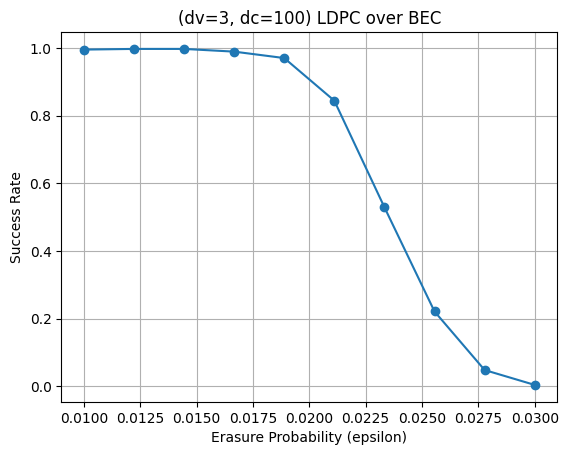

In [41]:
n = 5000; d_v = 3; d_c = 100
start, end = 0.01, 0.03
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.010, Success Rate=0.999
Epsilon=0.012, Success Rate=1.000
Epsilon=0.014, Success Rate=0.999
Epsilon=0.017, Success Rate=1.000
Epsilon=0.019, Success Rate=0.993
Epsilon=0.021, Success Rate=0.955
Epsilon=0.023, Success Rate=0.654
Epsilon=0.026, Success Rate=0.216
Epsilon=0.028, Success Rate=0.023
Epsilon=0.030, Success Rate=0.000


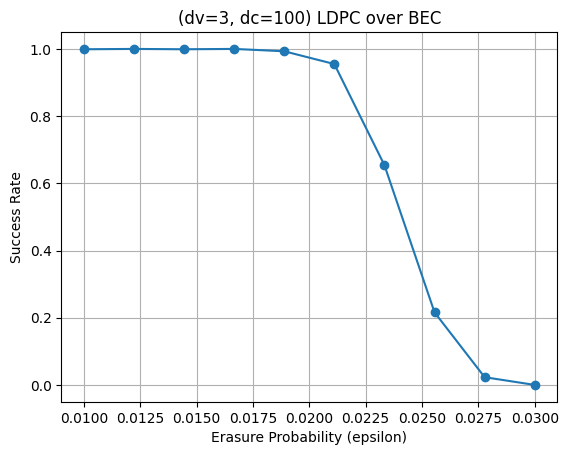

In [42]:
n = 10000; d_v = 3; d_c = 100
start, end = 0.01, 0.03
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.010, Success Rate=1.000
Epsilon=0.012, Success Rate=1.000
Epsilon=0.014, Success Rate=0.997
Epsilon=0.017, Success Rate=0.998
Epsilon=0.019, Success Rate=1.000
Epsilon=0.021, Success Rate=0.994
Epsilon=0.023, Success Rate=0.749
Epsilon=0.026, Success Rate=0.133
Epsilon=0.028, Success Rate=0.000
Epsilon=0.030, Success Rate=0.000


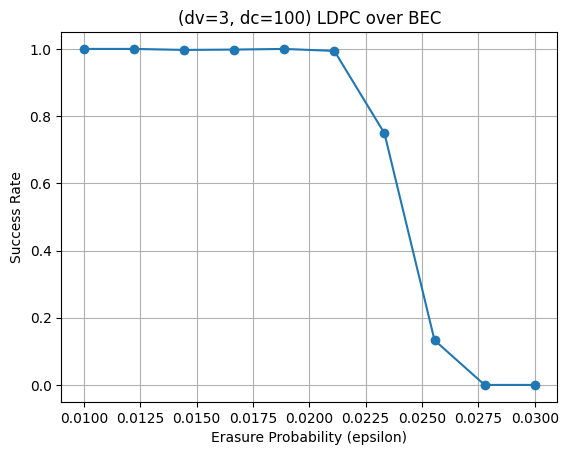

In [50]:
n = 20000; d_v = 3; d_c = 100
start, end = 0.01, 0.03
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.020, Success Rate=0.997
Epsilon=0.023, Success Rate=0.979
Epsilon=0.026, Success Rate=0.961
Epsilon=0.028, Success Rate=0.886
Epsilon=0.031, Success Rate=0.793
Epsilon=0.034, Success Rate=0.642
Epsilon=0.037, Success Rate=0.443
Epsilon=0.039, Success Rate=0.302
Epsilon=0.042, Success Rate=0.199
Epsilon=0.045, Success Rate=0.081


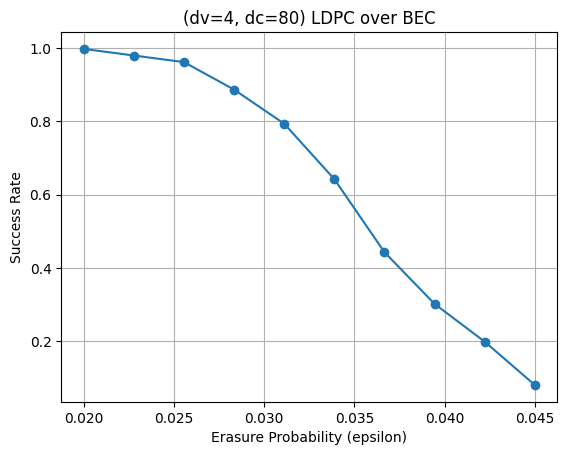

In [37]:
n = 1000; d_v = 4; d_c = 80
start, end = 0.02, 0.045
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.020, Success Rate=1.000
Epsilon=0.023, Success Rate=1.000
Epsilon=0.026, Success Rate=0.999
Epsilon=0.028, Success Rate=0.980
Epsilon=0.031, Success Rate=0.908
Epsilon=0.034, Success Rate=0.736
Epsilon=0.037, Success Rate=0.506
Epsilon=0.039, Success Rate=0.297
Epsilon=0.042, Success Rate=0.127
Epsilon=0.045, Success Rate=0.040


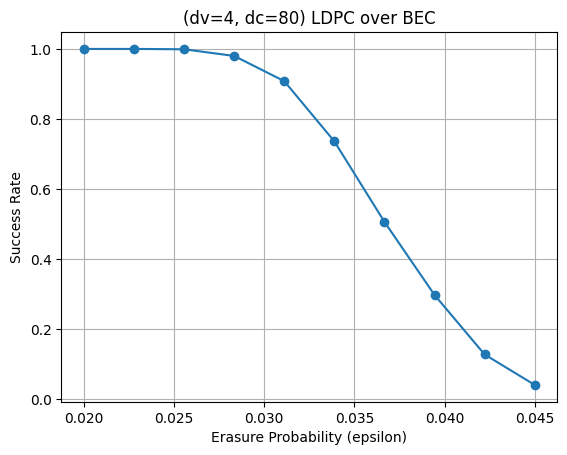

In [38]:
n = 2000; d_v = 4; d_c = 80
start, end = 0.02, 0.045
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.020, Success Rate=1.000
Epsilon=0.023, Success Rate=1.000
Epsilon=0.026, Success Rate=1.000
Epsilon=0.028, Success Rate=1.000
Epsilon=0.031, Success Rate=0.995
Epsilon=0.034, Success Rate=0.913
Epsilon=0.037, Success Rate=0.640
Epsilon=0.039, Success Rate=0.290
Epsilon=0.042, Success Rate=0.057
Epsilon=0.045, Success Rate=0.015


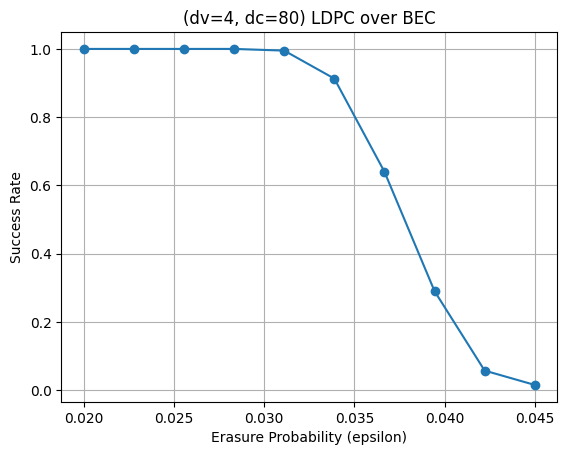

In [43]:
n = 5000; d_v = 4; d_c = 80
start, end = 0.02, 0.045
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.020, Success Rate=1.000
Epsilon=0.023, Success Rate=1.000
Epsilon=0.026, Success Rate=1.000
Epsilon=0.028, Success Rate=1.000
Epsilon=0.031, Success Rate=0.999
Epsilon=0.034, Success Rate=0.975
Epsilon=0.037, Success Rate=0.728
Epsilon=0.039, Success Rate=0.292
Epsilon=0.042, Success Rate=0.031
Epsilon=0.045, Success Rate=0.002


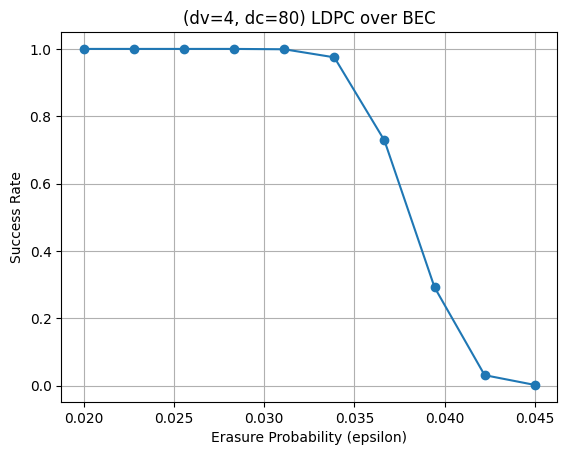

In [44]:
n = 10000; d_v = 4; d_c = 80
start, end = 0.02, 0.045
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.030, Success Rate=1.000
Epsilon=0.032, Success Rate=1.000
Epsilon=0.033, Success Rate=0.999
Epsilon=0.035, Success Rate=0.982
Epsilon=0.037, Success Rate=0.868
Epsilon=0.038, Success Rate=0.476
Epsilon=0.040, Success Rate=0.127
Epsilon=0.042, Success Rate=0.011
Epsilon=0.043, Success Rate=0.000
Epsilon=0.045, Success Rate=0.000


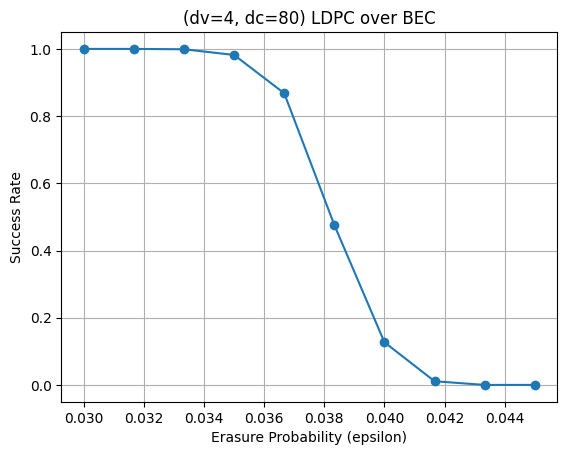

In [51]:
n = 20000; d_v = 4; d_c = 80
start, end = 0.03, 0.045
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.020, Success Rate=0.999
Epsilon=0.023, Success Rate=0.994
Epsilon=0.027, Success Rate=0.983
Epsilon=0.030, Success Rate=0.937
Epsilon=0.033, Success Rate=0.831
Epsilon=0.037, Success Rate=0.707
Epsilon=0.040, Success Rate=0.516
Epsilon=0.043, Success Rate=0.374
Epsilon=0.047, Success Rate=0.233
Epsilon=0.050, Success Rate=0.115


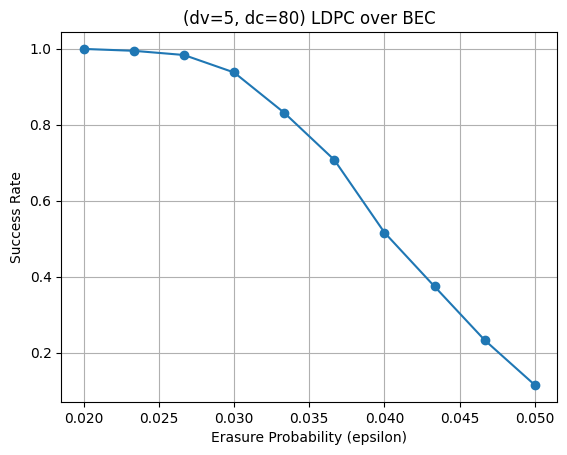

In [39]:
n = 800; d_v = 5; d_c = 80
start, end = 0.02, 0.05
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.020, Success Rate=1.000
Epsilon=0.023, Success Rate=1.000
Epsilon=0.027, Success Rate=0.998
Epsilon=0.030, Success Rate=0.995
Epsilon=0.033, Success Rate=0.956
Epsilon=0.037, Success Rate=0.827
Epsilon=0.040, Success Rate=0.626
Epsilon=0.043, Success Rate=0.376
Epsilon=0.047, Success Rate=0.178
Epsilon=0.050, Success Rate=0.083


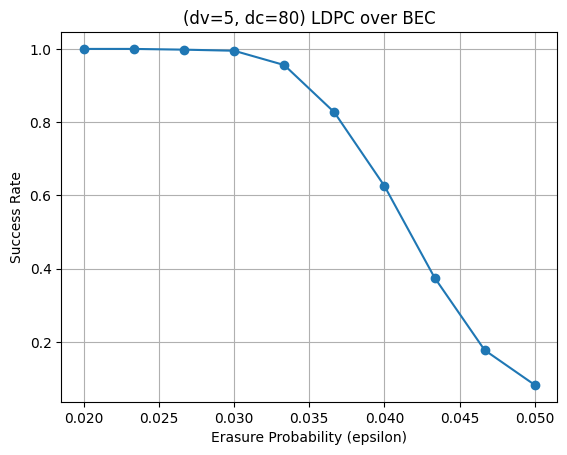

In [45]:
n = 1600; d_v = 5; d_c = 80
start, end = 0.02, 0.05
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.020, Success Rate=1.000
Epsilon=0.023, Success Rate=1.000
Epsilon=0.027, Success Rate=1.000
Epsilon=0.030, Success Rate=1.000
Epsilon=0.033, Success Rate=0.998
Epsilon=0.037, Success Rate=0.955
Epsilon=0.040, Success Rate=0.779
Epsilon=0.043, Success Rate=0.430
Epsilon=0.047, Success Rate=0.124
Epsilon=0.050, Success Rate=0.015


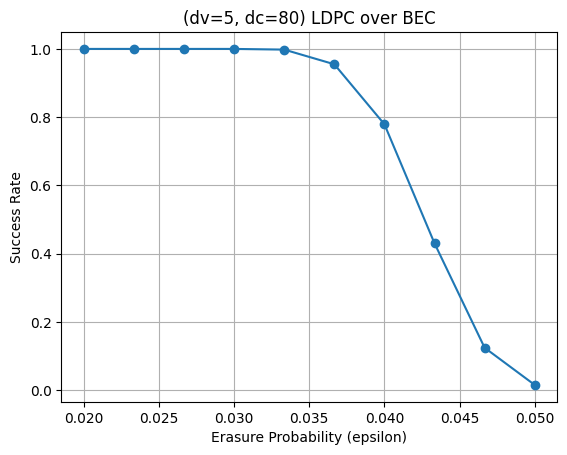

In [46]:
n = 4000; d_v = 5; d_c = 80
start, end = 0.02, 0.05
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.020, Success Rate=1.000
Epsilon=0.023, Success Rate=1.000
Epsilon=0.027, Success Rate=1.000
Epsilon=0.030, Success Rate=1.000
Epsilon=0.033, Success Rate=1.000
Epsilon=0.037, Success Rate=0.995
Epsilon=0.040, Success Rate=0.894
Epsilon=0.043, Success Rate=0.445
Epsilon=0.047, Success Rate=0.066
Epsilon=0.050, Success Rate=0.004


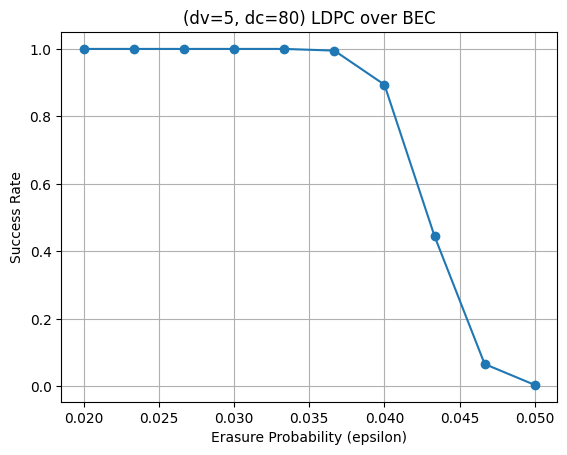

In [47]:
n = 8000; d_v = 5; d_c = 80
start, end = 0.02, 0.05
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.020, Success Rate=1.000
Epsilon=0.023, Success Rate=1.000
Epsilon=0.027, Success Rate=1.000
Epsilon=0.030, Success Rate=1.000
Epsilon=0.033, Success Rate=1.000
Epsilon=0.037, Success Rate=1.000
Epsilon=0.040, Success Rate=0.955
Epsilon=0.043, Success Rate=0.478
Epsilon=0.047, Success Rate=0.042
Epsilon=0.050, Success Rate=0.001


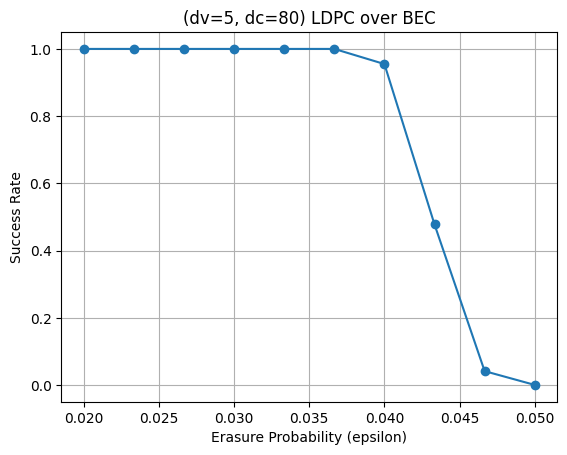

In [48]:
n = 12000; d_v = 5; d_c = 80
start, end = 0.02, 0.05
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.020, Success Rate=1.000
Epsilon=0.023, Success Rate=1.000
Epsilon=0.027, Success Rate=1.000
Epsilon=0.030, Success Rate=1.000
Epsilon=0.033, Success Rate=1.000
Epsilon=0.037, Success Rate=1.000
Epsilon=0.040, Success Rate=0.992
Epsilon=0.043, Success Rate=0.544
Epsilon=0.047, Success Rate=0.010
Epsilon=0.050, Success Rate=0.000


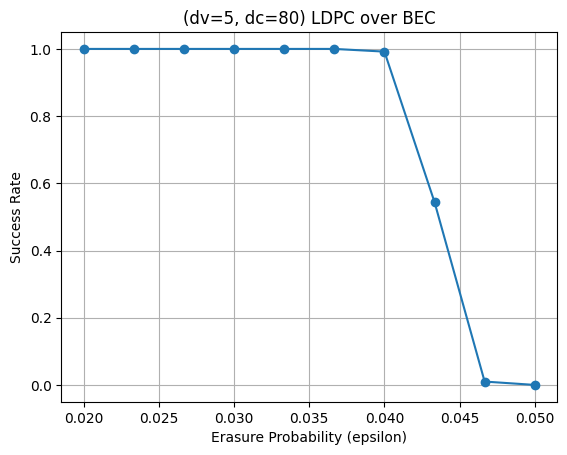

In [49]:
n = 24000; d_v = 5; d_c = 80
start, end = 0.02, 0.05
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.010, Success Rate=1.000
Epsilon=0.013, Success Rate=1.000
Epsilon=0.017, Success Rate=0.999
Epsilon=0.020, Success Rate=0.995
Epsilon=0.023, Success Rate=0.980
Epsilon=0.027, Success Rate=0.936
Epsilon=0.030, Success Rate=0.855
Epsilon=0.033, Success Rate=0.693
Epsilon=0.037, Success Rate=0.566
Epsilon=0.040, Success Rate=0.431


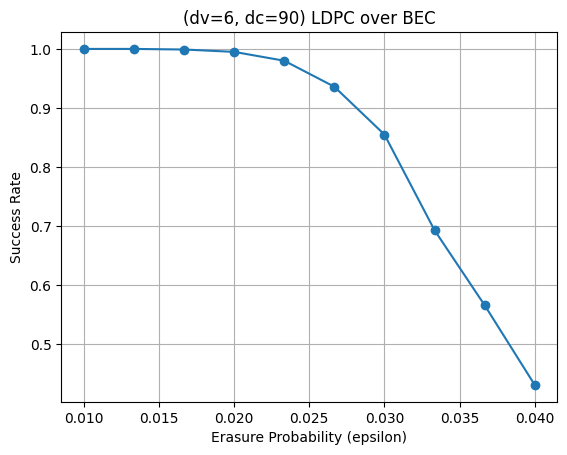

In [ ]:
np.random.seed(42)
n = 600; d_v = 6; d_c = 90
start, end = 0.01, 0.04
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.010, Success Rate=1.000
Epsilon=0.013, Success Rate=1.000
Epsilon=0.017, Success Rate=1.000
Epsilon=0.020, Success Rate=1.000
Epsilon=0.023, Success Rate=0.997
Epsilon=0.027, Success Rate=0.989
Epsilon=0.030, Success Rate=0.972
Epsilon=0.033, Success Rate=0.859
Epsilon=0.037, Success Rate=0.731
Epsilon=0.040, Success Rate=0.476


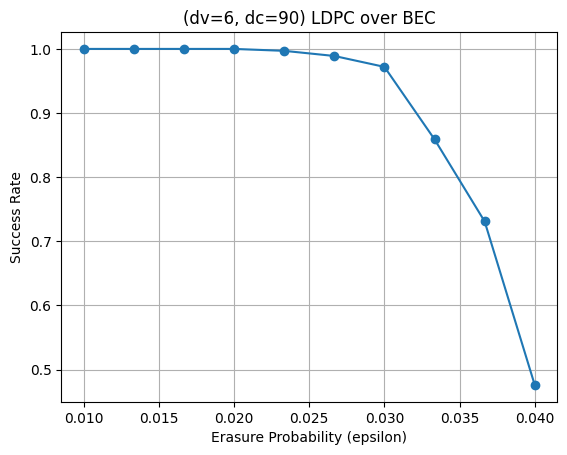

In [16]:
np.random.seed(42)
n = 1200; d_v = 6; d_c = 90
start, end = 0.01, 0.04
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.010, Success Rate=1.000
Epsilon=0.013, Success Rate=1.000
Epsilon=0.017, Success Rate=1.000
Epsilon=0.020, Success Rate=1.000
Epsilon=0.023, Success Rate=1.000
Epsilon=0.027, Success Rate=0.999
Epsilon=0.030, Success Rate=0.999
Epsilon=0.033, Success Rate=0.960
Epsilon=0.037, Success Rate=0.817
Epsilon=0.040, Success Rate=0.571


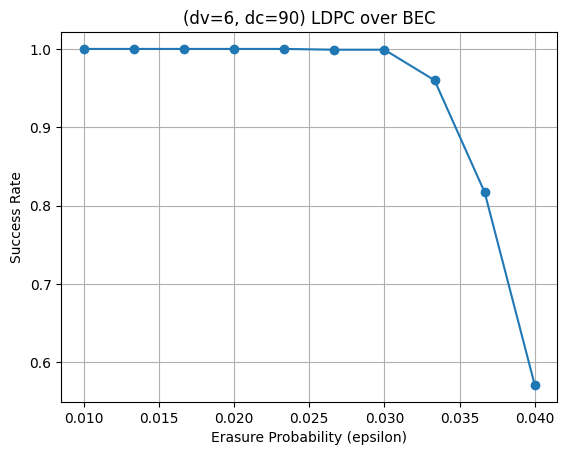

In [17]:
np.random.seed(42)
n = 2400; d_v = 6; d_c = 90
start, end = 0.01, 0.04
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.010, Success Rate=1.000
Epsilon=0.013, Success Rate=1.000
Epsilon=0.017, Success Rate=1.000
Epsilon=0.020, Success Rate=1.000
Epsilon=0.023, Success Rate=1.000
Epsilon=0.027, Success Rate=1.000
Epsilon=0.030, Success Rate=1.000
Epsilon=0.033, Success Rate=0.997
Epsilon=0.037, Success Rate=0.939
Epsilon=0.040, Success Rate=0.648


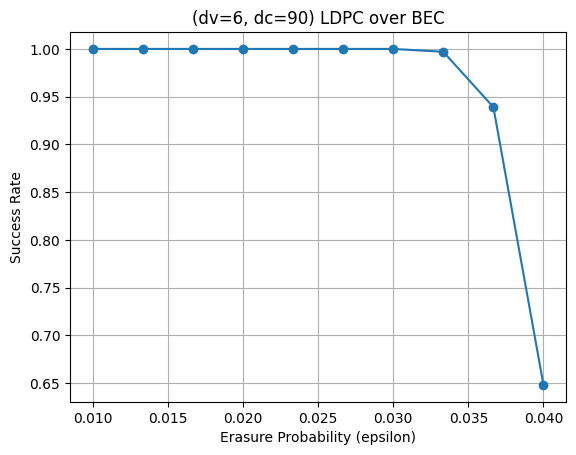

In [18]:
np.random.seed(42)
n = 4800; d_v = 6; d_c = 90
start, end = 0.01, 0.04
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.026, Success Rate=1.000
Epsilon=0.028, Success Rate=1.000
Epsilon=0.029, Success Rate=1.000
Epsilon=0.031, Success Rate=1.000
Epsilon=0.032, Success Rate=1.000
Epsilon=0.034, Success Rate=0.999
Epsilon=0.035, Success Rate=1.000
Epsilon=0.037, Success Rate=0.981
Epsilon=0.038, Success Rate=0.912
Epsilon=0.040, Success Rate=0.771


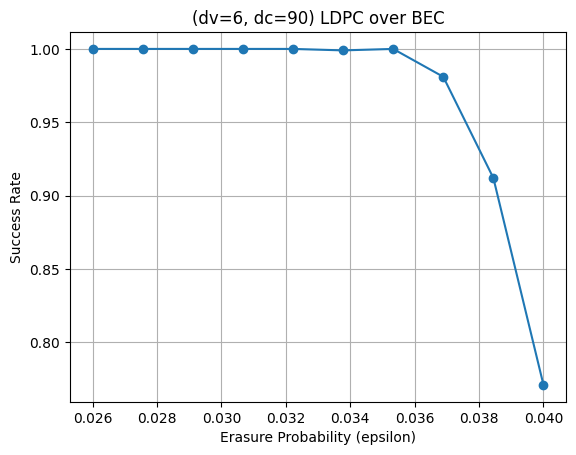

In [22]:
np.random.seed(42)
n = 9600; d_v = 6; d_c = 90
start, end = 0.026, 0.04
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.026, Success Rate=1.000
Epsilon=0.028, Success Rate=1.000
Epsilon=0.029, Success Rate=1.000
Epsilon=0.031, Success Rate=1.000
Epsilon=0.032, Success Rate=1.000
Epsilon=0.034, Success Rate=1.000
Epsilon=0.035, Success Rate=1.000
Epsilon=0.037, Success Rate=0.999
Epsilon=0.038, Success Rate=0.992
Epsilon=0.040, Success Rate=0.878


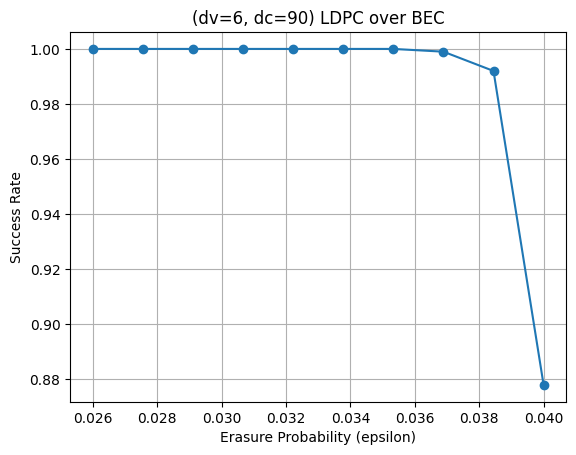

In [24]:
np.random.seed(42)
n = 19200; d_v = 6; d_c = 90
start, end = 0.026, 0.04
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.010, Success Rate=0.997
Epsilon=0.020, Success Rate=0.979
Epsilon=0.030, Success Rate=0.926
Epsilon=0.040, Success Rate=0.825
Epsilon=0.050, Success Rate=0.697
Epsilon=0.060, Success Rate=0.562
Epsilon=0.070, Success Rate=0.398
Epsilon=0.080, Success Rate=0.269
Epsilon=0.090, Success Rate=0.177
Epsilon=0.100, Success Rate=0.099


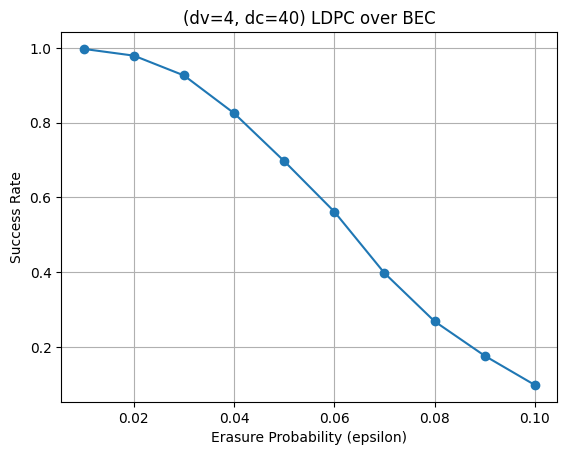

In [11]:
np.random.seed(42)
n = 100; d_v = 4; d_c = 40
start, end = 0.01, 0.1
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.010, Success Rate=1.000
Epsilon=0.020, Success Rate=0.999
Epsilon=0.030, Success Rate=0.982
Epsilon=0.040, Success Rate=0.934
Epsilon=0.050, Success Rate=0.838
Epsilon=0.060, Success Rate=0.638
Epsilon=0.070, Success Rate=0.451
Epsilon=0.080, Success Rate=0.282
Epsilon=0.090, Success Rate=0.145
Epsilon=0.100, Success Rate=0.077


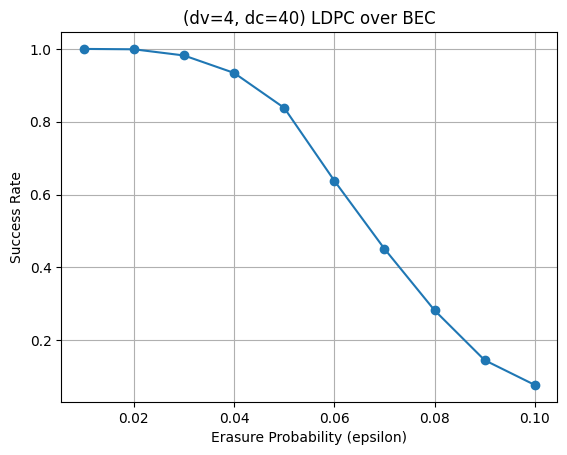

In [12]:
n = 200; d_v = 4; d_c = 40
start, end = 0.01, 0.1
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.030, Success Rate=1.000
Epsilon=0.032, Success Rate=1.000
Epsilon=0.034, Success Rate=1.000
Epsilon=0.037, Success Rate=0.999
Epsilon=0.039, Success Rate=0.998
Epsilon=0.041, Success Rate=0.997
Epsilon=0.043, Success Rate=0.995
Epsilon=0.046, Success Rate=0.990
Epsilon=0.048, Success Rate=0.979
Epsilon=0.050, Success Rate=0.974


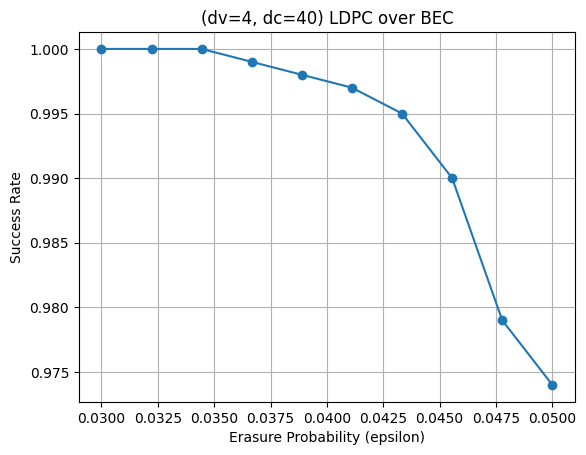

In [15]:
n = 500; d_v = 4; d_c = 40
start, end = 0.03, 0.05
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.040, Success Rate=1.000
Epsilon=0.043, Success Rate=0.999
Epsilon=0.047, Success Rate=1.000
Epsilon=0.050, Success Rate=0.997
Epsilon=0.053, Success Rate=0.994
Epsilon=0.057, Success Rate=0.976
Epsilon=0.060, Success Rate=0.944
Epsilon=0.063, Success Rate=0.886
Epsilon=0.067, Success Rate=0.798
Epsilon=0.070, Success Rate=0.656


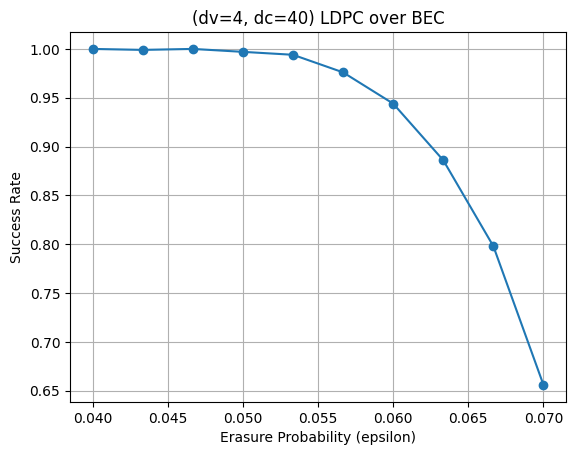

In [16]:
n = 1000; d_v = 4; d_c = 40
start, end = 0.04, 0.07
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.050, Success Rate=1.000
Epsilon=0.052, Success Rate=1.000
Epsilon=0.054, Success Rate=0.999
Epsilon=0.057, Success Rate=0.998
Epsilon=0.059, Success Rate=0.997
Epsilon=0.061, Success Rate=0.989
Epsilon=0.063, Success Rate=0.972
Epsilon=0.066, Success Rate=0.943
Epsilon=0.068, Success Rate=0.883
Epsilon=0.070, Success Rate=0.756


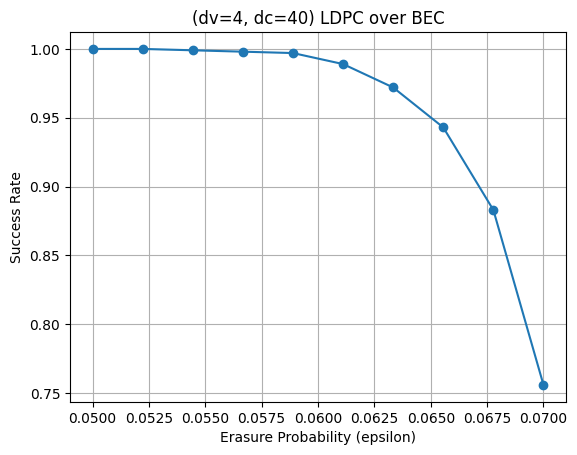

In [17]:
n = 2000; d_v = 4; d_c = 40
start, end = 0.05, 0.07
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.060, Success Rate=1.000
Epsilon=0.062, Success Rate=0.999
Epsilon=0.064, Success Rate=1.000
Epsilon=0.067, Success Rate=0.984
Epsilon=0.069, Success Rate=0.970
Epsilon=0.071, Success Rate=0.875
Epsilon=0.073, Success Rate=0.745
Epsilon=0.076, Success Rate=0.575
Epsilon=0.078, Success Rate=0.316
Epsilon=0.080, Success Rate=0.168


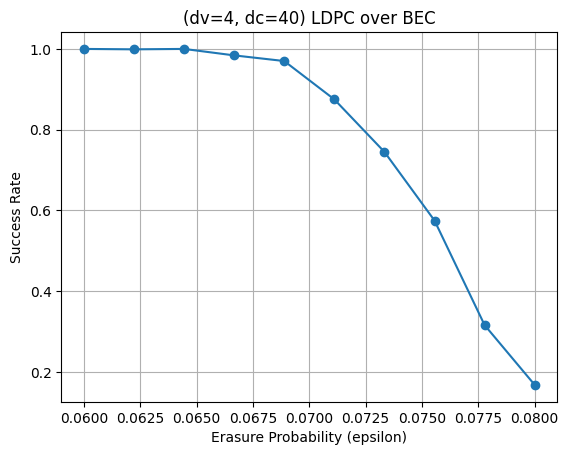

In [18]:
n = 5000; d_v = 4; d_c = 40
start, end = 0.06, 0.08
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.060, Success Rate=1.000
Epsilon=0.062, Success Rate=1.000
Epsilon=0.064, Success Rate=1.000
Epsilon=0.067, Success Rate=1.000
Epsilon=0.069, Success Rate=0.996
Epsilon=0.071, Success Rate=0.973
Epsilon=0.073, Success Rate=0.873
Epsilon=0.076, Success Rate=0.652
Epsilon=0.078, Success Rate=0.324
Epsilon=0.080, Success Rate=0.109


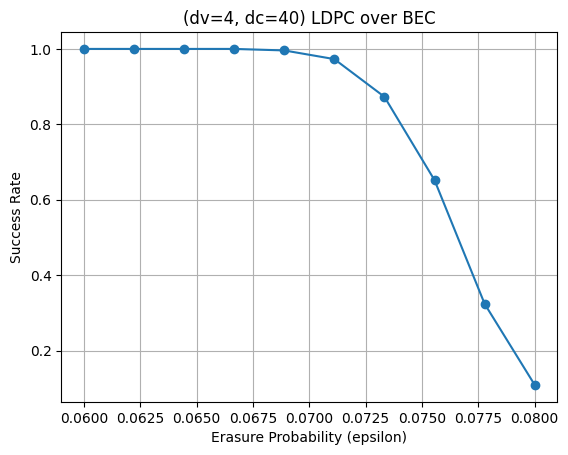

In [19]:
n = 10000; d_v = 4; d_c = 40
start, end = 0.06, 0.08
run_experiment(n, d_v, d_c, start=start, end=end)

Epsilon=0.060, Success Rate=1.000
Epsilon=0.063, Success Rate=1.000
Epsilon=0.067, Success Rate=1.000
Epsilon=0.070, Success Rate=1.000
Epsilon=0.073, Success Rate=0.945
Epsilon=0.077, Success Rate=0.538
Epsilon=0.080, Success Rate=0.062
Epsilon=0.083, Success Rate=0.001
Epsilon=0.087, Success Rate=0.000
Epsilon=0.090, Success Rate=0.000


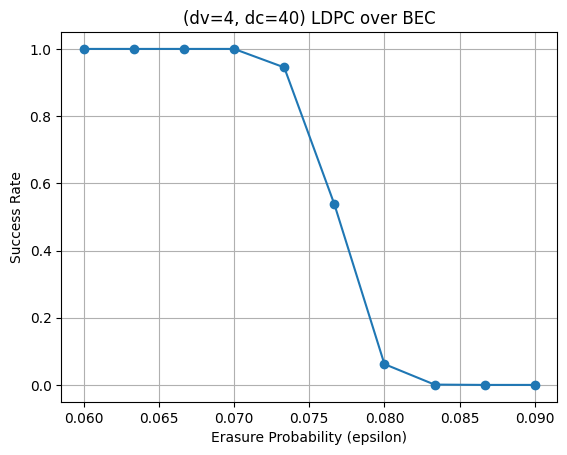

In [9]:
n = 20000; d_v = 4; d_c = 40
start, end = 0.06, 0.09
run_experiment(n, d_v, d_c, start=start, end=end)